# 2.1 Getting started with ROS2 and MVSim

Time to get our hands dirty! 🤖

In this chapter we are going to take our first steps with the
[Robot Operating System 2 (ROS2) ecosystem](https://docs.ros.org/en/jazzy/index.html), the *de facto* standard
framework for developing robotic software, and with
[MVSim](https://mvsimulator.readthedocs.io/en/latest/index.html), the simulator that will play the role of our
robot and its environment:

> Lightweight, realistic dynamical simulator for 2D ("2.5D") vehicles and robots. It is tailored to analysis of
vehicle dynamics, wheel-ground contact forces, and accurate simulation of typical robot sensors.
This project includes C++ and Python libraries, the standalone CLI application mvsim, and ROS 1 and ROS 2 nodes,
and it is licensed under the permissive 3-clause BSD License.

<figure style="text-align:center">
  <img src="https://raw.githubusercontent.com/jotaraul/robotics_hub/main/robot_control_architecture/images/mvsim_overview.png" alt="" width="750">
  <figcaption>Fig. 1: MVSim (front window) simulating a robot equipped with a depth camera, together with RViz2 (background) displaying the data that the simulator publishes to ROS2.</figcaption>
</figure>

MVSim is an **open source** project: its code, documentation and a good number of examples are available at
[github.com/MRPT/mvsim](https://github.com/MRPT/mvsim). It was created by
[Jose Luis Blanco-Claraco](https://github.com/jlblancoc), a former colleague of the [MAPIR](https://mapir.uma.es/mapirwebsite/) research group.

By the end of this notebook you will be able to inspect a simulated world, understand which information the robot
publishes and consumes, command it manually, and write a ROS2 node: a program that lets you drive the robot with
your keyboard.

## 2.1.1 How to work with this notebook

**This notebook is different from the notebooks you have used so far: it is not meant to be run.** ROS2 is a distributed system made of several programs
(*nodes*) running and talking to each other at the same time, so it does not fit into a notebook: it has to be run
on your own machine.

Therefore, from now on this notebook plays the role of a **lab guide and report**: you keep it open while you work
on your computer, where you will have a number of terminals running ROS2 commands, and you write your answers back
into it — commands, screenshots and code.

Concretely, you will be asked for three kinds of evidence:

1. **Commands**: paste the command you found (and, when asked, its output) into a new markdown code block below, like this:
   ```bash
   ros2 --help
   ```
2. **Screenshots**: a capture of the simulator, of RViz2 or of a terminal.
3. **Code**: the source of the node you develop, pasted in a markdown code block.

**Assumed setup.** We take for granted that, following the seminar and the campus tutorial, you already have a
working installation of:

- **Ubuntu 24.04**
- **ROS2 Jazzy Jalisco**, with its environment variables loaded in every new terminal
  (i.e. `source /opt/ros/jazzy/setup.bash` added to your `~/.bashrc`)
- **MVSim**, installed as a ROS2 package (`ros-jazzy-mvsim`)

*Tip: a terminal multiplexer like `terminator` (`sudo apt install terminator`) makes your life much easier here,
since you will typically need 3-4 terminals at the same time.*

## 2.1.2 Insight into MVSim

MVSim describes everything about a simulation in a **world file**, an XML file with the extension `.world.xml`. This
file tells the simulator what the environment looks like (walls, floors, 3D meshes, elevation maps...), which
vehicles populate it, which sensors those vehicles carry, and how the graphical interface should behave.

MVSim ships with a good number of ready-to-use demo worlds. They live inside the installed package, in a directory
called `mvsim_tutorial`, together with their launch files and RViz2 configurations. A sibling directory,
`definitions`, contains reusable building blocks (vehicle classes, sensor definitions) that worlds *include*.

In this notebook we are going to work with the **`demo_indoor_outdoor`** world, which combines an indoor
scenario with an outdoor one, a nice playground for navigation, localization and mapping. This is a (trimmed)
excerpt of its world file, so you get the idea of its structure:

```xml
<mvsim_world version="1.0">
  <!-- General simulation options -->
  <simul_timestep>0</simul_timestep>

  <!-- GUI options -->
  <gui>
    <ortho>false</ortho>
    <cam_distance>35</cam_distance>
    <refresh_fps>20</refresh_fps>
  </gui>

  <!-- ==========================
              Scenario
       ========================== -->
  <element class="horizontal_plane"> ... </element>
  <element class="occupancy_grid">   ... </element>

  <!-- ==========================
        Vehicle classes definition
       ========================== -->
  <include file="../definitions/jackal.vehicle.xml"
    default_sensors="true"
    lidar2d_raytrace="true"
    lidar2d_fov_degrees="360"
    joyMaxLinSpeed="3.0"
  />

  <!-- ==========================
            Vehicle(s)
       ========================== -->
  <vehicle name="robot" class="jackal">
    <init_pose>0 0 0</init_pose>   <!-- In global coords: x, y, yaw(deg) -->

    <!-- Extra sensors, added on top of the ones of the vehicle class -->
    <include file="../definitions/gnss.sensor.xml"
      sensor_x="0.0" sensor_y="0.0" sensor_z="0.25"
      sensor_period_sec="1.0" sensor_name="gps1" />

    <include file="../definitions/imu.sensor.xml"
      sensor_x="0.0" sensor_y="0.0" sensor_z="0.5"
      sensor_period_sec="$f{1/200.0}" />
  </vehicle>

</mvsim_world>
```

Two ideas are worth highlighting here:

- **`<include>` promotes reuse.** The robot is not described in the world file: the world just *includes* the
  `jackal` vehicle class, defined elsewhere. The same happens with sensors. This way, the same robot or the same
  laser scanner can be dropped into many different worlds.
- **Includes are parameterized.** Those `attribute="value"` pairs in an `<include>` are arguments. Inside the
  included file you will find expressions like `${sensor_yaw|0.0}`, meaning *"use the value of `sensor_yaw` given by
  whoever includes me, and if nobody gives one, use `0.0`"*. Some blocks are even conditional, wrapped in
  `<if condition="${default_sensors|true}"> ... </if>`.

<figure style="text-align:center">
  <img src="https://raw.githubusercontent.com/jotaraul/robotics_hub/main/robot_control_architecture/images/mvsim_demo_indoor_outdoor.png" alt="" width="750">
  <figcaption>Fig. 2: The <code>demo_indoor_outdoor</code> world in MVSim: an indoor office connected to an outdoor terrain with hills and a pylon, with the robot's onboard RGB camera view shown in the bottom-right inset.</figcaption>
</figure>

### **<span style="color:green"><b><i>ASSIGNMENT 1: Exploring a world file</i></b></span>**

Let's have a look at the real thing.

**What to do?**

1. Find out where the demo worlds of MVSim were installed in your system. *Hint: ROS2 packages install their
   resources under `share/<package_name>/`, and there is a `ros2 pkg` subcommand that tells you the prefix of an
   installed package, so you do not have to guess the path.* Write below the command you used and the resulting path.



```bash
ros2 pkg prefix mvsim
# /opt/ros/jazzy
```


2. Inside that folder, open `mvsim_tutorial/demo_indoor_outdoor.world.xml` with your favourite editor and answer
   the following questions:

   - How many vehicles are there in the world, and what are their **names** and **classes**?

     Hay 1 vehículo en el mundo. Su nombre es robot y su clase es jackal.

   - In which file is the `jackal` vehicle class actually defined? Open it too: which **sensors** does it mount when the
     `default_sensors` argument is true?

     La clase se define en ../definitions/jackal.vehicle.xml. Cuando el argumento default_sensors es verdadero, monta un escáner láser 2D, un LiDAR 3D y una cámara RGB.

   - Which **extra sensors** does the world file add to the robot, on top of the ones coming from its class?

     El archivo del mundo añade un receptor GNSS (gps1) y una IMU (imu) adicionales a los de su clase.

**A note on the real robot.** The `jackal` class of MVSim models the
[Clearpath Jackal](https://clearpathrobotics.com/jackal-small-unmanned-ground-vehicle/), a small outdoor platform
used in many research labs. It is worth knowing which of those sensors a real Jackal actually carries, because only
some of them come with the robot:

- **Integrated in the base platform**: the **wheel encoders**, which are the source of the odometry, an onboard
  **IMU** and an onboard **GPS** receiver, which is what makes it an outdoor-capable robot.
- **Optional payloads**, mounted on its top plate depending on what each lab buys: 2D laser scanners, 3D LiDARs,
  cameras, high-precision RTK GNSS receivers, lightweight manipulators...

The two payloads that our simulated robot carries are a
[Hokuyo UTM-30LX](https://www.robotshop.com/es/products/telemetro-de-escaneo-laser-hokuyo-utm-30lx-ew) 2D laser
scanner and a [RoboSense Helios-32](https://store.robosense.ai/products/helios-series?variant=44365447692341)
3D LiDAR, while its camera, GNSS and IMU do not model any particular commercial device.


### **<span style="color:green"><b><i>ASSIGNMENT 2: Building a lighter, GPU-friendly world</i></b></span>**

As you have just discovered, our robot carries a **32-beam 3D LiDAR** and an **RGB camera**, among others. MVSim renders both
through the GPU (OpenGL), so on a computer without a decent GPU (or inside a virtual machine, where 3D acceleration
is often limited) the simulation may crawl or even fail to start.

In this first, introductory notebook to the simulator we do not really need either of them: a 2D laser scanner is
more than enough. Those three sensors come from the **`jackal` vehicle class**, and they are all wrapped in the same
`<if condition="${default_sensors|true}">` block, so a single argument switches the three of them off at once.

That is exactly what we are going to do — and then mount the 2D laser scanner **ourselves**, directly in the world
file, the same way the GNSS and the IMU are already mounted there. Every edit of this assignment goes into
`demo_indoor_outdoor.world.xml`, and none into the vehicle class file: since `jackal.vehicle.xml` is shared by every
world of the system installation, it is much cleaner to leave it untouched and configure our robot from the world
that uses it.

**What to do?**

1. Open `mvsim_tutorial/demo_indoor_outdoor.world.xml` with your favourite editor. Since it belongs to the system
   installation, you will need `sudo` to save your changes.


```bash
sudo nano /opt/ros/jazzy/share/mvsim/mvsim_tutorial/demo_indoor_outdoor.world.xml
```


2. Find the `<include>` of the `jackal` vehicle class and set its `default_sensors` argument to `false`, so the
   robot arrives with no sensors at all. While you are there, note that `lidar2d_raytrace` and `lidar2d_fov_degrees`
   only configured the scanner mounted by the class, which no longer exists — so you can drop them too. Paste below
   the piece of XML you changed:


```xml
<include file="../definitions/jackal.vehicle.xml"
        default_sensors="false"
        joyMaxLinSpeed="3.0"
        />
```


3. Now give the robot its 2D laser scanner back, this time from the world file. Inside the `<vehicle name="robot">`
   tag, right before the GNSS include, add this one (no need to type it, just copy it):

```xml
<!-- 2D laser scanner, mounted at the front of the robot and looking forward -->
<include file="../definitions/lidar2d.sensor.xml"
  sensor_x="0.15"  sensor_y="0.0" sensor_z="0.25" sensor_yaw="0"
  sensor_period_sec="0.10"
  sensor_name="scanner1"
  raytrace_3d="true"
  fov_degrees="270"
  />
```

   Paste below the resulting `<vehicle>` block:


```xml
<vehicle name="robot" class="jackal">
        <init_pose>$f{-CORRIDOR_STRAIGHT_LENGTH-0.5*INDOOR_ROOM_SIZE-5} 0 0</init_pose>

        <include file="../definitions/lidar2d.sensor.xml"
          sensor_x="0.15"  sensor_y="0.0" sensor_z="0.25" sensor_yaw="0"
          sensor_period_sec="0.10"
          sensor_name="scanner1"
          raytrace_3d="true"
          fov_degrees="270"
          />

        <include file="../definitions/gnss.sensor.xml"
          sensor_x="0.0"  sensor_y="0.0" sensor_z="0.25"
          sensor_period_sec="1.0"
          sensor_name="gps1"
          sensor_horizontal_std_noise="1.5"
          sensor_vertical_std_noise="2.5"
          />

        <include file="../definitions/imu.sensor.xml"
          sensor_x="0.0"  sensor_y="0.0" sensor_z="0.5" sensor_yaw="0"
          sensor_name="imu"
          sensor_measure_orientation="true"
          sensor_period_sec="$f{1/200.0}"
          sensor_angular_velocity_white_noise_std_noise="1.7e-4"
          sensor_linear_acceleration_white_noise_std_noise="5.88e-3"
          sensor_angular_velocity_random_walk_std_noise="1.0e-5"
          sensor_linear_acceleration_random_walk_std_noise="3.0e-4"
        />
</vehicle>
```


Take a moment to look at those arguments, since they are a good example of how much a sensor's **placement** matters:

- `sensor_x="0.15"`, `sensor_yaw="0"`: the scanner sits at the **front** of the robot, looking **forward**. The
  `jackal` class mounted it the other way around (`sensor_x="-0.15"`, `sensor_yaw="180"`, at the back looking
  backwards), which for this notebook is far less intuitive.
- `fov_degrees="270"`: a 270° field of view, typical of real indoor laser scanners, instead of the unrealistic 360°
  the class was using.
- `raytrace_3d="true"`: the rays are traced against the **real 3D geometry** of the scene (walls, furniture, trees),
  not against a flat 2D map. This is more realistic, but it also means that anything standing in the way of the
  scanner blocks it — including the robot's own sensors! This is precisely what happened with the original
  configuration: the camera and the 3D LiDAR, mounted on the top plate right in front of the scanner, punched a
  hole in its readings (see Fig. 3). Now that both of them are gone, the problem disappears.


<figure style="text-align:center">
  <img src="https://raw.githubusercontent.com/jotaraul/robotics_hub/main/robot_control_architecture/images/jackal_gnss_lidar_occlusion.png" alt="" width="600">
  <figcaption>Fig. 3: The robot with the <b>original</b> configuration (scanner at the back, looking backwards, 360&deg; FOV and <code>lidar2d_raytrace="true"</code>). The visual models of the camera and of the 3D LiDAR stand in the way of the scanner and block part of its rays &mdash; notice the gap in the scanned circle right behind them.</figcaption>
</figure>


Both changes live in `demo_indoor_outdoor.world.xml`, so no other world of your installation is affected: the
`jackal` class keeps its full sensor suite for whoever needs it. Launch the world again and take a look at your
robot: the bulky 3D LiDAR and the camera are gone, and a single laser scanner now sits at its front (Fig. 4) — not
far, by the way, from how a real Jackal comes out of the factory.

**Note**: if your computer does have a good GPU, feel free to undo these changes later and compare how much
smoother the simulation feels with the full sensor suite. 😉


<figure style="text-align:center">
  <img src="https://raw.githubusercontent.com/jotaraul/robotics_hub/main/robot_control_architecture/images/jackal_single_lidar2d.png" alt="" width="600">
  <figcaption>Fig. 4: The robot after Assignment 2, at its starting position in the outdoor area: the only sensor left with a visual model is the 2D laser scanner, mounted at the front and looking forward.</figcaption>
</figure>

## 2.1.3 Launching a simulation

A **launch file** starts a set of nodes, with their parameters, all at once. MVSim provides one launch file per demo
world, plus a generic one, `launch/launch_world.launch.py`, which takes any world file as an argument, useful for
worlds of your own that do not ship with a launch file.

Launch files are just Python scripts. This is a (trimmed) excerpt of
`mvsim_tutorial/demo_indoor_outdoor.launch.py`, so you get the idea of its structure:

```python
def generate_launch_description():
    mvsim_dir = get_package_share_directory('mvsim')
    world_file = os.path.join(mvsim_dir, 'mvsim_tutorial', 'demo_indoor_outdoor.world.xml')

    headless = LaunchConfiguration('headless')
    use_rviz = LaunchConfiguration('use_rviz')
    # ... one LaunchConfiguration per argument ...

    ld = LaunchDescription()

    ld.add_action(DeclareLaunchArgument(
        'headless', default_value='False', description='Run in headless mode'
    ))
    ld.add_action(DeclareLaunchArgument(
        'use_rviz', default_value='True', description='Whether to launch RViz2'
    ))
    # ... one DeclareLaunchArgument per argument ...

    ld.add_action(IncludeLaunchDescription(
        PythonLaunchDescriptionSource(
            os.path.join(get_package_share_directory('mvsim'), 'launch', 'launch_world.launch.py')
        ),
        launch_arguments={
            'world_file': world_file,
            'headless': headless,
            'use_rviz': use_rviz,
            # ... the rest of the arguments ...
        }.items()
    ))

    return ld
```

Two ideas are worth highlighting here:

- **`DeclareLaunchArgument`** declares one command-line argument, together with its default value and
  description.
- **`IncludeLaunchDescription`** reuses another launch file instead of duplicating its logic — the same "include"
  idea you already saw in world files, now applied to launch files. Here it includes the generic
  `launch_world.launch.py`, passing it the world file path and the declared arguments.

`demo_indoor_outdoor.launch.py` does not start any node itself, though — it just includes `launch_world.launch.py`,
the generic launch file that does the actual work. This is a (trimmed) excerpt of it:

```python
def generate_launch_description():
    world_file_launch_arg = DeclareLaunchArgument(
        "world_file", description='Path to the *.world.xml file to load')
    use_rviz_arg = DeclareLaunchArgument(
        'use_rviz', default_value='True', description='Whether to launch RViz2')
    # ... one DeclareLaunchArgument per argument ...

    mvsim_node = Node(
        package='mvsim',
        executable='mvsim_node',
        name='mvsim',
        output='screen',
        parameters=[{
            "world_file": LaunchConfiguration('world_file'),
            # ... the rest of the parameters ...
        }]
    )

    rviz2_node = Node(
        condition=IfCondition(LaunchConfiguration('use_rviz')),
        package='rviz2',
        executable='rviz2',
        name='rviz2',
    )

    return LaunchDescription([
        world_file_launch_arg,
        use_rviz_arg,
        # ... the rest of the arguments ...
        mvsim_node,
        rviz2_node
    ])
```

Two more ideas worth highlighting:

- **`Node(...)`** is the action that actually starts a ROS2 node — here, `mvsim_node` and `rviz2`, each one
  configured with the values coming from the declared arguments. This is where the two windows you are about to see
  really come from.
- **`condition=IfCondition(...)`** makes a node conditional: `rviz2` is only launched if the `use_rviz` argument
  evaluates to true. This is also why `headless` can turn off the MVSim GUI window without touching anything else.

Note also that this file builds its `LaunchDescription` all at once, listing every action inside
`LaunchDescription([...])`, instead of adding them one by one with `ld.add_action(...)` like
`demo_indoor_outdoor.launch.py` did — both styles are equivalent, it is just a matter of taste.

For `demo_indoor_outdoor`, that launch file is `demo_indoor_outdoor.launch.py`:

```bash
ros2 launch mvsim demo_indoor_outdoor.launch.py
```

Go ahead and run it now — thanks to your edits in Assignment 2 it should run smoothly even without a powerful
GPU. Both kinds of
launch files start the simulator node (`mvsim_node`) and, optionally, **RViz2**. Do not confuse the two windows that
will pop up:

- The **MVSim GUI** is the simulator itself: it is the *ground truth*, the (fake) reality where our robot lives.
- **[RViz2](https://docs.ros.org/en/jazzy/p/rviz2/)** is a general-purpose ROS2 visualizer. It knows nothing about MVSim: everything it draws (the robot, the
  laser readings, the map) arrives through ROS2 topics. It is the *robot's view of the world*, which is exactly what
  a real robot's software would see.

### **<span style="color:green"><b><i>ASSIGNMENT 3: Launching the world</i></b></span>**

**What to do?**

1. Include here a **screenshot** showing both the MVSim GUI and the RViz2 window from the simulation you just
   launched.
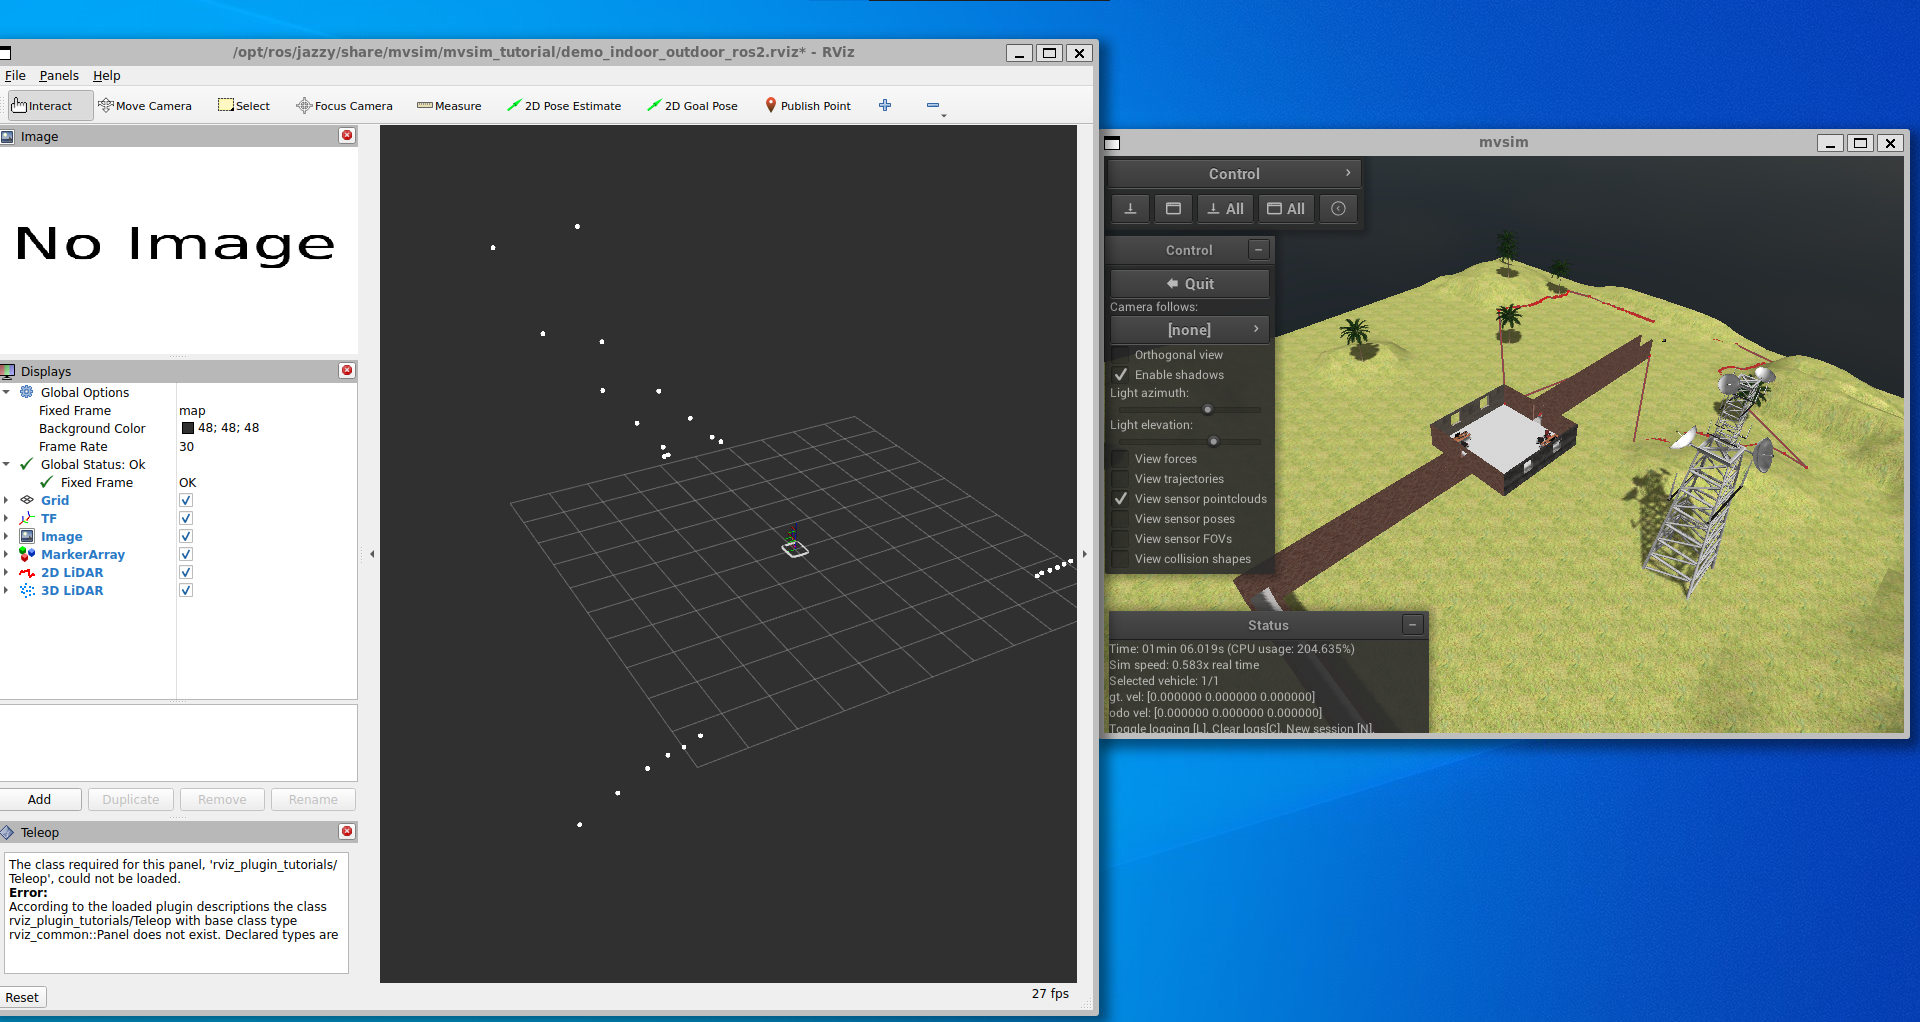


2. Stop it (`Ctrl+C` on the terminal, or close the MVSim GUI). Launch files accept arguments — find out **which
   arguments** this one accepts, without opening the file. *Hint: launch files support the `--help` flag, just like
   any other CLI command.* Write the command you ended up using, and the list it prints, below.


```bash
ros2 launch mvsim demo_indoor_outdoor.launch.py --show-args
```


   Los argumentos que acepta este archivo de lanzamiento son: headless, do_fake_localization, publish_tf_odom2baselink, force_publish_vehicle_namespace, use_rviz, publish_log_topics, world_file, disable_sim_time_clock y rviz_config_file.

3. Relaunch it, this time passing a value for one of those arguments straight from the command line (hint:
   `argument:=value`), so that the MVSim GUI window does **not** open, but RViz2 still does. Which argument did you
   use, and with what value?


El argumento utilizado es headless con el valor True.

### **<span style="color:green"><b><i>ASSIGNMENT 4: Analyzing the topics</i></b></span>**

Nodes in ROS2 talk to each other by publishing and subscribing to **topics**, each one carrying messages of a given
**type**. Let's find out what our simulated robot is offering and expecting. Stop the headless run from
Assignment 3 and launch the simulation again in its normal mode (`ros2 launch mvsim demo_indoor_outdoor.launch.py`,
no extra arguments). Keep it running and, in *another* terminal, investigate it.

**What to do?** Find and write down the commands needed to:

- List all the topics currently available.


```bash
/amcl_pose
/base_pose_ground_truth
/cam1/image_raw
/chassis_markers
/chassis_polygon
/clicked_point
/clock
/cmd_vel
/collision
/goal_pose
/gps1
/imu
/initialpose
/lidar1_points
/odom
/parameter_events
/particlecloud
/rosout
/scanner1
/simul_map
/simul_map_metadata
/tf
/tf_static
```


- Show detailed information about one topic (its type, and how many publishers and subscribers it has). *Hint:
  there is a flag that also shows the publisher/subscriber count.*


```bash
ros2 topic info /scanner1 -v
Type: sensor_msgs/msg/LaserScan

Publisher count: 1

Node name: mvsim
Node namespace: /
Topic type: sensor_msgs/msg/LaserScan
Topic type hash: RIHS01_64c191398013af96509d518dac71d5164f9382553fce5c1f8cca5be7924bd828
Endpoint type: PUBLISHER
GID: 01.0f.00.01.cb.02.b1.c6.00.00.00.00.00.00.23.03
QoS profile:
  Reliability: RELIABLE
  History (Depth): UNKNOWN
  Durability: VOLATILE
  Lifespan: Infinite
  Deadline: Infinite
  Liveliness: AUTOMATIC
  Liveliness lease duration: Infinite

Subscription count: 1

Node name: rviz2
Node namespace: /
Topic type: sensor_msgs/msg/LaserScan
Topic type hash: RIHS01_64c191398013af96509d518dac71d5164f9382553fce5c1f8cca5be7924bd828
Endpoint type: SUBSCRIPTION
GID: 01.0f.a6.25.cc.02.2a.20.00.00.00.00.00.00.30.04
QoS profile:
  Reliability: RELIABLE
  History (Depth): UNKNOWN
  Durability: VOLATILE
  Lifespan: Infinite
  Deadline: Infinite
  Liveliness: AUTOMATIC
  Liveliness lease duration: Infinite
```


- Print on screen the messages being published in the laser scanner topic.


```bash
ros2 topic echo /scanner1

---
header:
  stamp:
    sec: 1790591756
    nanosec: 928955078
  frame_id: scanner1
angle_min: -2.356194496154785
angle_max: 2.356194496154785
angle_increment: 0.02617993950843811
time_increment: 0.0
scan_time: 0.0
range_min: 0.019999999552965164
range_max: 30.0
ranges:
- 5.334865093231201
- 5.52176570892334
- 5.621490955352783
- 5.785524368286133
- 5.900417804718018
```


- Measure how often (Hz) those laser messages are published. *Hint: same family of subcommands as
  `list`/`info`/`echo` — take a look at `ros2 topic --help`.*


```bash
ros2 topic hz /scanner1

average rate: 9.583
        min: 0.079s max: 0.126s std dev: 0.01278s window: 11
average rate: 9.721
        min: 0.079s max: 0.126s std dev: 0.01393s window: 21
average rate: 9.782
        min: 0.079s max: 0.126s std dev: 0.01332s window: 31
```


- Display, graphically, which nodes exist and how they are connected through topics.


```bash
rqt_graph
```


  Include here a **screenshot** of `rqt_graph`.


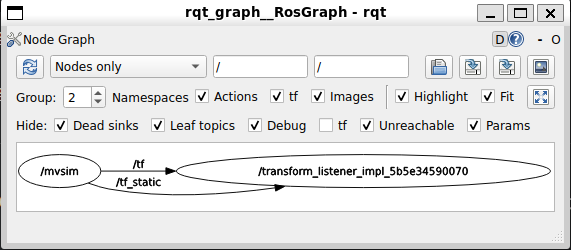

Now, fill in the following table with the **5 topics you think are most relevant** to the simulation. The first
row is filled in for you, by courtesy, as an example of the level of detail expected:

| Topic | Message type | Published by | Subscribed by | What does it carry? |
|---|---|---|---|---|
| `/scanner1` | `sensor_msgs/msg/LaserScan` | `mvsim` | `rviz2` | Range readings of the 2D laser scanner |
| `/odom` | `nav_msgs/msg/Odometry` | `mvsim` | `rviz2` | Odometry data (estimated position and velocity) |
| `/cmd_vel` | `geometry_msgs/msg/Twist` | External nodes (e.g., teleop) | `mvsim` | Velocity commands to move the robot |
| `/tf` | `tf2_msgs/msg/TFMessage` | `mvsim` | `rviz2` | Dynamic coordinate transformations between frames |
| `/imu` | `sensor_msgs/msg/Imu` | `mvsim` | `rviz2` | Inertial data (linear acceleration and angular velocity) |

### <font color="blue"><b><i>Thinking about it (1)</i></b></font>

Having explored the simulation, **answer the following questions**:

- The simulator publishes both `/odom` and `/base_pose_ground_truth`. What is the difference between them? Which one
  would be available in a **real** robot, and which one would you use to *evaluate* how well a localization
  algorithm works?

  La diferencia principal es que /odom es la posición estimada del robot calculada a partir de las lecturas de sus sensores (odometría), la cual acumula ruido y errores con el tiempo. Por el contrario, /base_pose_ground_truth es la coordenada exacta y perfecta del robot proporcionada por el motor físico del simulador. En un robot real únicamente estaría disponible /odom. Para evaluar el rendimiento de un algoritmo de localización se utiliza /base_pose_ground_truth, empleándolo como referencia absoluta para medir los errores del algoritmo.

- Nobody is publishing in `/cmd_vel` yet, but the topic already exists. Why?

  El tópico existe porque el nodo del simulador (mvsim) ha creado un suscriptor para /cmd_vel durante su inicio para quedar a la escucha de comandos. En la arquitectura de ROS 2, un tópico se registra y es visible en el sistema desde el momento en que al menos un nodo se suscribe a él o publica en él, sin requerir que ambas partes existan simultáneamente.

- If you closed RViz2 and left only the simulator running, would the laser scanner keep being simulated and
  published? What does this tell you about how ROS2 nodes depend on each other?

  Sí, el simulador continuaría calculando y publicando las lecturas del láser. Esto demuestra que los nodos en ROS 2 están completamente desacoplados y son independientes. El nodo publicador (mvsim) emite la información de los sensores a sus respectivos tópicos sin importar si existe o no un nodo suscriptor (rviz2) conectado para recibirla y procesarla.

## 2.1.4 Commanding the robot

Among the topics you have just listed, there is one the simulator is **subscribed** to: `/cmd_vel`. It expects
messages of type `geometry_msgs/msg/Twist`, which encode a velocity command expressed in the robot's own frame:

- `linear.x` → forward/backward velocity, in m/s
- `angular.z` → rotational velocity around the vertical axis, in rad/s

The remaining components (`linear.y`, `linear.z`, `angular.x`, `angular.y`) simply do not apply to a differential
drive robot moving on the ground, so they are left at zero.

Remember that `ros2 topic pub` has a few flags that control **how many times**, and how often, it sends that
message:

- With no extra flags, it **keeps publishing the same message repeatedly** (at a default rate of 1 Hz) until you
  stop it with <kbd>Ctrl+C</kbd>.
- `--once` publishes the message **a single time** and exits immediately.
- `--rate <hz>` lets you choose the publishing frequency yourself, instead of the default.


### **<span style="color:green"><b><i>ASSIGNMENT 5: Manually controlling the robot</i></b></span>**

**What to do?**

1. Without writing a single line of code, make the robot **move forward** by publishing directly from the terminal.
   *Hint: you already know how to publish messages from the terminal with `ros2 topic pub` — do the same here, on
   `/cmd_vel`.*


```bash
ros2 topic pub /cmd_vel geometry_msgs/msg/Twist "{linear: {x: 1.0, y: 0.0, z: 0.0}, angular: {x: 0.0, y: 0.0, z: 0.0}}"
```


   Now try the same command with `--once` instead. What do you observe? Does the robot keep moving forever, or
   does it stop by itself after a while, even though you never told it to?


Al utilizar la bandera --once, el robot avanza ligeramente y luego se detiene por sí solo al cabo de un corto periodo de tiempo. No sigue moviéndose para siempre. Esto sucede porque el sistema implementa un mecanismo de seguridad (conocido como watchdog o temporizador). Si el robot deja de recibir mensajes de velocidad de forma periódica en /cmd_vel, asume que se ha perdido la conexión con el nodo de control y detiene automáticamente los motores por seguridad.


2. Make it **turn on the spot**, and then **stop** it.


```bash
ros2 topic pub /cmd_vel geometry_msgs/msg/Twist "{linear: {x: 0.0, y: 0.0, z: 0.0}, angular: {x: 0.0, y: 0.0, z: 0.5}}"

ros2 topic pub --once /cmd_vel geometry_msgs/msg/Twist "{linear: {x: 0.0, y: 0.0, z: 0.0}, angular: {x: 0.0, y: 0.0, z: 0.0}}"
```


3. Take a **screenshot** showing the robot at a spot **different** from where it started, and paste it here
   together with the commands you used.

   ros2 topic pub /cmd_vel geometry_msgs/msg/Twist "{linear: {x: 0.8, y: 0.0, z: 0.0}, angular: {x: 0.0, y: 0.0, z: 0.3}}"
   

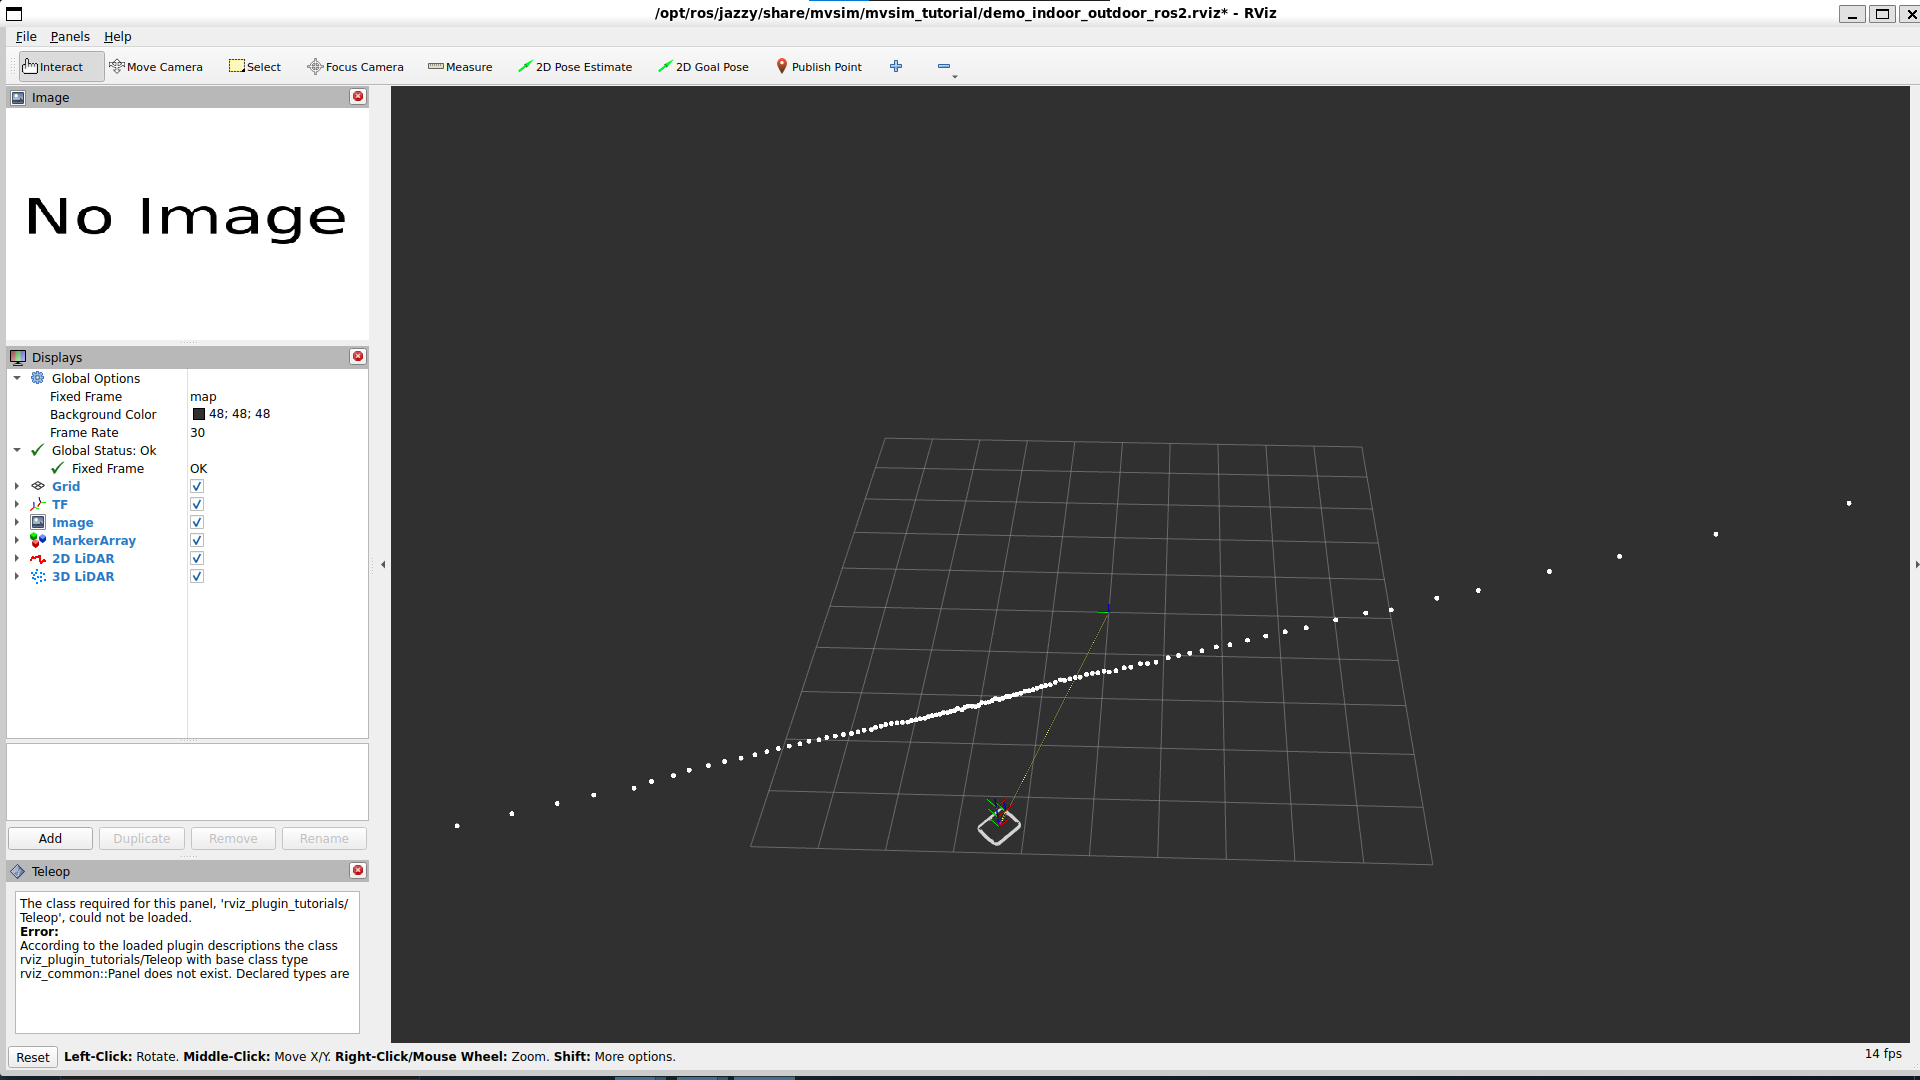

⚠️ Drive carefully, the robot can crash against the walls! If it gets stuck and you are not sure how to fix it,
you can always restart the simulation (`Ctrl+C` it and launch it again).

### <font color="blue"><b><i>Thinking about it (2)</i></b></font>

- You just saw MVSim stop the robot by itself a short while after you stopped publishing to `/cmd_vel`, even
  without sending an explicit stop command. Why do you think MVSim (and most real robot controllers) implement
  this kind of **watchdog**, instead of just keeping applying the last velocity forever?

  Se implementa por motivos críticos de seguridad. Si el programa de control falla, el ordenador se bloquea o la conexión de red se pierde, el robot dejaría de recibir comandos. Si el robot mantuviera la última velocidad recibida de forma indefinida, acabaría chocando irremediablemente contra obstáculos o personas. El watchdog asegura que el robot frene automáticamente ante cualquier pérdida de comunicación para evitar daños.

- The command you sent is expressed in the robot's own coordinate frame, not in world coordinates. Why is that
  convenient for the person (or program) driving the robot?

  Expresar las velocidades en el marco de referencia local del robot simplifica el control, ya que comandos como "avanzar" o "girar a la izquierda" siempre significan lo mismo sin importar la ubicación u orientación exacta del robot en el mapa. Esto es muy conveniente porque permite a un operador humano (o a un algoritmo) conducir el vehículo de forma intuitiva, sin necesidad de calcular transformaciones trigonométricas continuas ni de conocer las coordenadas globales (localización) del robot en el mundo.

## 2.1.5 A ROS2 workspace, package and node of your own

Publishing commands by hand is fun for about two minutes. Let's do it properly: we are going to write a **node**
that reads the keyboard and translates each key press into a velocity command. On the way, we will go through the
standard ROS2 development pipeline:

<figure style="text-align:center">
  <img src="https://raw.githubusercontent.com/jotaraul/robotics_hub/main/robot_control_architecture/images/ros2_development_pipeline.png" alt="">
  <figcaption>Fig. 5: The usual ROS2 development pipeline: workspace &rarr; package &rarr; node &rarr; build &rarr; run.</figcaption>
</figure>

Remember the following concepts before starting:

- A **workspace** is just a directory where you develop and build your own ROS2 code. It contains a `src/`
  subdirectory with your packages, and after building it, three more (`build/`, `install/`, `log/`) generated by the
  build tool, **colcon**.
- A **package** is the unit of organization and distribution of ROS2 code. It has a name, a `package.xml` declaring
  its dependencies, and (for Python packages) a `setup.py` declaring, among other things, its **entry points**: the
  executables it provides.
- A **node** is a program that participates in the ROS2 graph, publishing and/or subscribing to topics. Our node
  will be a **publisher** of `/cmd_vel`.
- After building, you must **source** the workspace (`install/setup.bash`) in every terminal where you want to use
  it, exactly as you did with `/opt/ros/jazzy/setup.bash`.

Some handy links:
[workspace](https://docs.ros.org/en/jazzy/Tutorials/Beginner-Client-Libraries/Creating-A-Workspace/Creating-A-Workspace.html),
[package](https://docs.ros.org/en/jazzy/Tutorials/Beginner-Client-Libraries/Creating-Your-First-ROS2-Package.html),
[publisher/subscriber](https://docs.ros.org/en/jazzy/Tutorials/Beginner-Client-Libraries/Writing-A-Simple-Py-Publisher-And-Subscriber.html).

### **<span style="color:green"><b><i>ASSIGNMENT 6: Creating the workspace and the package</i></b></span>**

**What to do?**

1. *(Optional if you already have a working ROS2 workspace.)* Create one in your home directory (we suggest
   `~/robotics_ws`), build it while it is still empty (yes, it works!) and add its `setup.bash` to your
   `~/.bashrc`, so every new terminal knows about it.



```bash
mkdir -p ~/robotics_ws/src
cd ~/robotics_ws
colcon build
echo "source ~/robotics_ws/install/setup.bash" >> ~/.bashrc
```


2. Create inside it a Python package named `robot_teleop`, which depends on `rclpy` and `geometry_msgs`, and which
   already contains a node called `keyboard_control`. *A package's dependencies are simply the other ROS2
   packages your code needs to import: `rclpy` is the Python client library that lets you write nodes at all, and
   `geometry_msgs` provides the `Twist` message type you will publish. Declaring them now saves you from having to
   add them by hand to `package.xml` afterwards.* ⚠️ Packages are created inside the `src/` directory!



```bash
cd ~/robotics_ws/src
ros2 pkg create --build-type ament_python robot_teleop --dependencies rclpy geometry_msgs --node-name keyboard_control
```


3. Explore what has been generated and include a **screenshot** of the contents of `~/robotics_ws/src/robot_teleop`.
   Which file declares the executable that will be run? And which one declares the dependencies?

   El archivo que declara el ejecutable (el entry point) que se ejecutará es setup.py.

   El archivo que declara las dependencias necesarias para el código es package.xml.

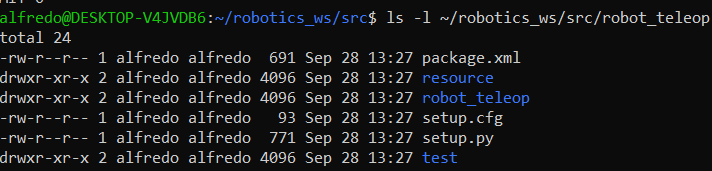

### **<span style="color:green"><b><i>ASSIGNMENT 7: Implementing the keyboard teleoperation node</i></b></span>**

Time to write some code. Your node must:

- Read **single key presses** from the terminal, without needing to hit <kbd>Enter</kbd> after each one.
- Translate them into velocity commands: at the very least, **move forward** (key `w`), **move backward**
  (key `s`), **turn left** (key `a`), **turn right** (key `d`) and **stop** (key `space`).
- **Publish** those commands as `geometry_msgs/msg/Twist` messages in the `/cmd_vel` topic.
- Print a small help message, so the user knows which keys to press.

*Hints:*
- *The publisher/subscriber tutorial linked above already shows the skeleton of a node: the constructor
  (`__init__`), the `create_publisher` call and the `main()` boilerplate (`rclpy.init` / `spin` / `destroy_node` /
  `shutdown`) follow exactly the same pattern here — you can reuse that structure as a starting skeleton.*
- *What's new is reading the keyboard **without** waiting for <kbd>Enter</kbd>, since that example node did not
  read any user input. The standard trick in Python is to put the terminal in "raw" mode with the `termios` and `tty`
  modules, and to use `select` to check, on each loop iteration, whether a key is waiting to be read — instead of
  a subscriber callback, you will likely need a loop (or another `create_timer`) that polls the keyboard. Here is
  a ready-to-use helper function for that part, so you can focus on the ROS2 side of the node:*

  ```python
  import select
  import sys
  import termios
  import tty


  def read_key(timeout=0.1):
      """Return the key pressed by the user, or '' if none was pressed."""
      settings = termios.tcgetattr(sys.stdin)
      try:
          tty.setraw(sys.stdin.fileno())
          ready, _, _ = select.select([sys.stdin], [], [], timeout)
          return sys.stdin.read(1) if ready else ''
      finally:
          # Always leave the terminal as we found it!
          termios.tcsetattr(sys.stdin, termios.TCSADRAIN, settings)
  ```
- *`rclpy.spin()` blocks until the node is shut down, so it cannot be used here if you need to keep polling the
  keyboard yourself in a loop — look for a non-blocking alternative, such as `rclpy.spin_once(node, timeout_sec=0.0)`.*

**What to do?**

1. Implement the node in `~/robotics_ws/src/robot_teleop/robot_teleop/keyboard_control.py`.
2. Paste below the code of your node.



```python
import rclpy
from rclpy.node import Node
from geometry_msgs.msg import Twist

import select
import sys
import termios
import tty

def read_key(timeout=0.1):
    """Return the key pressed by the user, or '' if none was pressed."""
    settings = termios.tcgetattr(sys.stdin)
    try:
        tty.setraw(sys.stdin.fileno())
        ready, _, _ = select.select([sys.stdin], [], [], timeout)
        return sys.stdin.read(1) if ready else ''
    finally:
        # Always leave the terminal as we found it!
        termios.tcsetattr(sys.stdin, termios.TCSADRAIN, settings)

class KeyboardTeleop(Node):
    def __init__(self):
        super().__init__('keyboard_control')
        # Crear publicador en el tópico /cmd_vel
        self.publisher_ = self.create_publisher(Twist, '/cmd_vel', 10)
        self.get_logger().info('Nodo de teleoperación iniciado.')
        self.print_help()

    def print_help(self):
        print("""
-------------------------------------------
Control manual del robot (MVSim)
-------------------------------------------
Usa las siguientes teclas para moverte:
  w : Avanzar
  s : Retroceder
  a : Girar a la izquierda
  d : Girar a la derecha
  Espacio : Detener el robot

Pulsa Ctrl+C para salir.
-------------------------------------------
        """)

def main(args=None):
    rclpy.init(args=args)
    node = KeyboardTeleop()

    msg = Twist()
    linear_vel = 1.0
    angular_vel = 0.5

    try:
        while rclpy.ok():
            # Procesar callbacks pendientes sin bloquear la ejecución
            rclpy.spin_once(node, timeout_sec=0.0)
            
            # Leer el teclado
            key = read_key(0.1)

            if key == '\x03':  # Ctrl+C detectado
                break

            publish = False

            if key == 'w':
                msg.linear.x = linear_vel
                msg.angular.z = 0.0
                publish = True
            elif key == 's':
                msg.linear.x = -linear_vel
                msg.angular.z = 0.0
                publish = True
            elif key == 'a':
                msg.linear.x = 0.0
                msg.angular.z = angular_vel
                publish = True
            elif key == 'd':
                msg.linear.x = 0.0
                msg.angular.z = -angular_vel
                publish = True
            elif key == ' ':
                msg.linear.x = 0.0
                msg.angular.z = 0.0
                publish = True

            if publish:
                node.publisher_.publish(msg)

    except Exception as e:
        print(e)
    finally:
        # Publicar velocidad 0 antes de cerrar por seguridad
        stop_msg = Twist()
        node.publisher_.publish(stop_msg)
        node.destroy_node()
        rclpy.shutdown()

if __name__ == '__main__':
    main()
```


3. Build the workspace again (`colcon build`).
4. Run it with `ros2 run robot_teleop keyboard_control` while the simulation is running.
5. Record your screen (or take a few screenshots) showing how you drive the robot around with your node, and include
   the result here.

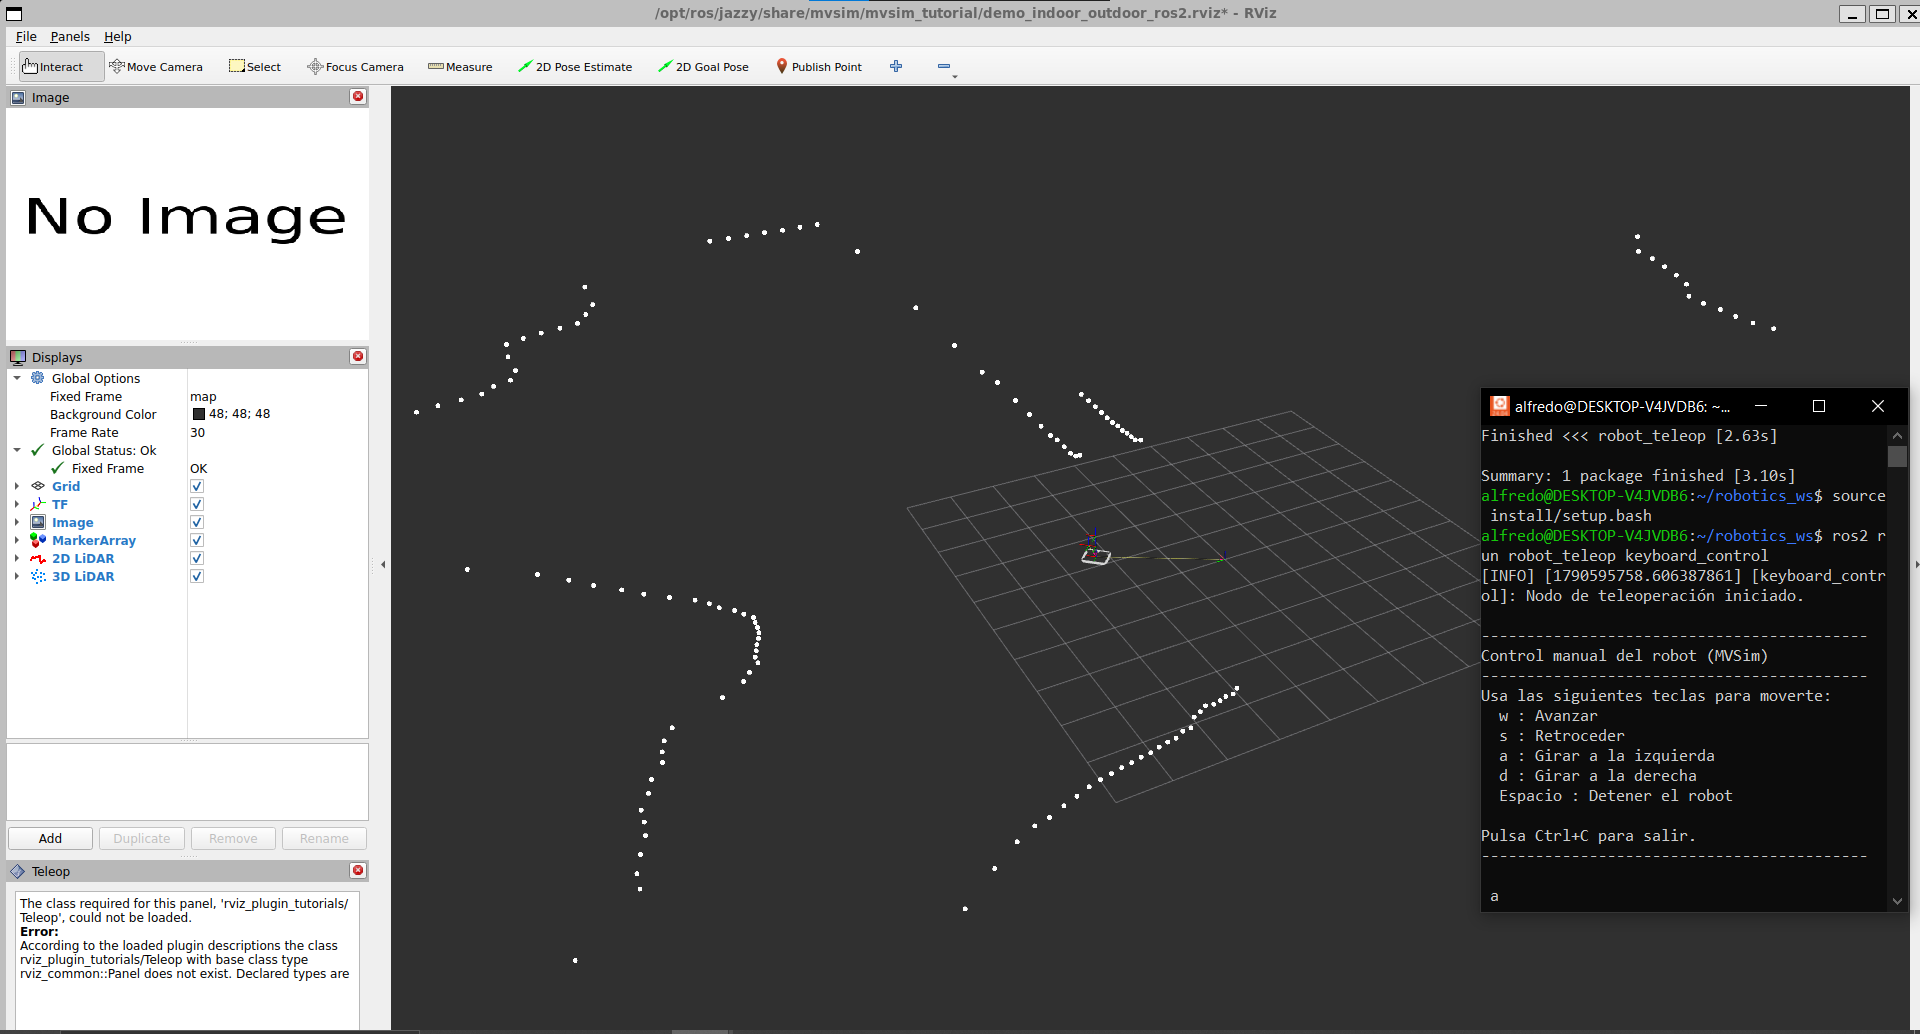

6. With your node running, check again the ROS2 graph (`rqt_graph`). Has it changed? Include the new screenshot.

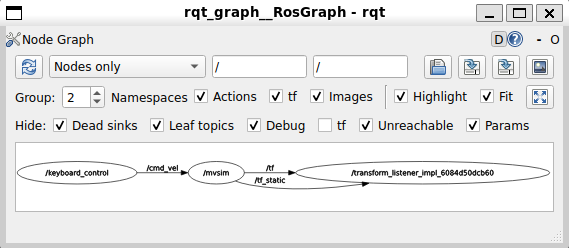

Sí, el grafo ha cambiado. Ahora aparece un nuevo nodo llamado /keyboard_control que actúa como publicador. Este nodo está conectado mediante una flecha al tópico /cmd_vel, el cual a su vez dirige otra flecha hacia el nodo /mvsim, demostrando que el simulador está suscrito a los comandos de velocidad que emite nuestro nuevo nodo.

### **<span style="color:green"><b><i>OPTIONAL: Try other worlds</i></b></span>**

MVSim comes with many other demo worlds (`demo_warehouse`, `demo_greenhouse`, `demo_2robots`,
`demo_turtlebot_world`...). Try your teleoperation node in a couple of them and discuss the results: does it work
out of the box? What happens in `demo_2robots`, where there is more than one robot? *Hint: take a look at the
`force_publish_vehicle_namespace` launch argument, and at how topic names change.*

<p style="margin: 4px 0px 6px 5px; color:blue"><i>Your answer here!</i></p>

### **<span style="color:green"><b><i>OPTIONAL: Improve your node</i></b></span>**

The node above is as simple as it gets. Pick one or more improvements and implement them:

- Make the topic name configurable through a ROS2 **parameter**, instead of hardcoding `/cmd_vel`, so the same node
  can drive different robots.
- Implement smooth **acceleration and deceleration** instead of jumping instantly between velocities.
- Add a **watchdog**: if no key has been pressed for a given time, publish a zero velocity automatically.
- Subscribe to the laser scanner and **refuse to move forward** if there is an obstacle too close, a first taste of
  reactive navigation techniques.

Describe below what you implemented and how it improves the behaviour of the robot.

<p style="margin: 4px 0px 6px 5px; color:blue"><i>Your answer here!</i></p>

### **<span style="color:green"><b><i>OPTIONAL: Do it in C++</i></b></span>**

ROS2 is a multi-language ecosystem: nodes written in different languages interoperate transparently, since they only
talk through topics. Rewrite your teleoperation node in **C++** (`rclcpp` instead of `rclpy`), in a package created
with `--build-type ament_cmake`, and check that the robot behaves exactly the same.

Pay attention to what changes: the `CMakeLists.txt` file now describes how to compile and install your executable,
and dependencies are declared both there and in `package.xml`.

Paste here the code of your C++ node and a screenshot of it in action.

<p style="margin: 4px 0px 6px 5px; color:blue"><i>Your answer here!</i></p>

## <font color="orange"><b><i>AI Appendix</i></b></font>

### A.1 How I used AI
- **Model/tool:**
  Gemini
- **What I asked AI to help with (bullets):**
  Desarrollar el código del nodo en Python utilizando lectura de teclado no bloqueante.
- **Best prompt I used (paste):**
 "Escribe un nodo en Python para ROS 2 llamado keyboard_control que lea las teclas W, A, S, D y la barra espaciadora del terminal sin necesidad de pulsar Enter. El nodo debe publicar mensajes de tipo geometry_msgs/Twist en el tópico /cmd_vel utilizando rclpy.spin_once() en un bucle para no bloquear la ejecución."
- **What I kept vs. changed from the AI output:**
  Mantuve: El código en Python proporcionado para el nodo keyboard_control, la estructura del bucle principal con rclpy.spin_once(), la función read_key para la lectura de teclado no bloqueante y los comandos de terminal para la creación del paquete en ROS 2.
  Cambie: Ajuste de velocidades. Modifiqué los valores de las variables linear_vel y angular_vel en el código. Probando el nodo en el simulador mvsim, ajusté las velocidades para que el movimiento del robot fuera más suave y controlable en el entorno.

### A.2 AI review
Ask one generative AI to review your memo using this prompt:

```
Act as a technical reviewer of this mobile robotics lab notebook. Read my memo and return exactly 5 bullet points:

- two on theory (key ideas),
- two on practice (relevant programming concepts of python used, not particular functions or variables),
- one on how to improve the code (most critical aspect: limitations, parameter choices, runtime/robustness, possible bugs).

Keep each bullet ≤15 words and make them specific to my work.
```

Paste its **5** items here:

- **(Theory 1)** AI claim:
  ROS 2 usa una arquitectura publicador-suscriptor desacoplada mediante tópicos como /cmd_vel.
- **(Theory 2)** AI claim:
  Un mecanismo de seguridad (watchdog) detiene al robot si los comandos de velocidad cesan.
- **(Practice 1)** AI claim:
  La ejecución asíncrona y E/S no bloqueante permiten leer el teclado sin detener el programa.
- **(Practice 2)** AI claim:
  Mecanismos de sondeo en el bucle principal procesan callbacks del nodo sin esperas indefinidas.
- **(Improvement)** AI claim:
  Fijar velocidades en el código reduce flexibilidad; usar parámetros de ROS 2 permitiría configuración dinámica.

Finally, **do you agree with them?**, **would you have selected others?**
    Sí, estoy de acuerdo con los puntos. La parte teórica refleja tal cual lo que estuvimos probando con el simulador, en especial cómo actuaba el watchdog cuando dejábamos de mandar comandos. Sobre la práctica, gestionar la entrada del teclado sin que se quedase colgado el nodo fue la parte más compleja del código, así que tiene sentido que destaque el uso del bucle asíncrono. En cuanto a la mejora, me parece muy acertada: tener las velocidades puestas a fuego (hardcodeadas) en el código es poco práctico. Usar parámetros de ROS 2 nos ahorraría tener que abrir y editar el archivo fuente cada vez que queramos probar el robot a distinta velocidad.